# 各装置结构数据 → IMAS 数据入口 → 极向截面图

这一册做三件事，一件接一件，每一步的**命令行与产出文件**都留在输出里：

1. 问 `fy` 这份发行版认识哪些装置，哪几台带**结构数据**（线圈 · 真空室 · 诊断位置）；
2. 逐台用 `fy data convert … --layout imas --to hdf5` 写成一个 **IMAS 数据入口**；
3. 把入口**读回来**，用 `fylite.machine_svg` 画成极向截面示意图（SVG，矢量）。

★★第三步不是装饰。前两步的产物是一堆数，「数对不对」看不出来；而几何一旦在转换中
错位——轮廓的 `r` 和 `z` 落到两个地方、矩形展开时倾角丢了——**图上立刻是错的**。
所以这一册的判据是：**画出来的机器，和源文档里的那台，是同一台**。

★这里的每一条结论都有对应的闸子守着，不靠这一册跑一次：
`python/tests/test_device_export_integrity.py`（逐值核对 · 丢失基线 · 截面前后一致）
与 `python/tests/test_machine_svg.py`（几何读取 · 矩形展开 · viewBox · 零依赖）。

In [1]:
import json, os, subprocess, sys, tempfile
from pathlib import Path

#: 仓根：从这一册往上找，找到带 `python/fylite` 的那一层
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "python" / "fylite").is_dir())
sys.path.insert(0, str(ROOT / "python"))

from fylite import facts, machine_svg          # noqa: E402
from fylite.io import fydoc                    # noqa: E402

#: `fy` 是构建产物，不在仓里。装了发行版就在 PATH 上；本仓检出里在 target/release/
FY = next((p for p in [ROOT / "rust/fylite_runtime/target/release/fy"] if p.is_file()), None)
print("repo :", ROOT)
print("fy   :", FY or "PATH 上的 fy（本册的导出一步需要它）")
print("facts:", facts.bundled_count(), "个条目编译在二进制里")

repo : /home/user/fylite
fy   : /home/user/fylite/rust/fylite_runtime/target/release/fy
facts: 6 个条目编译在二进制里


## 一 · 这份发行版认识哪些装置

`fy list devices` 只读，不取任何东西。**装置描述随发行版编译在二进制里**
（2026-09-05 裁定），所以下面这一步在一台没有任何语料检出的机器上也答得出来。

In [2]:
print(subprocess.run([str(FY), "list", "devices"], capture_output=True, text=True).stdout)

device           described  licence  from
best             card       yes      /home/user/fylite/dist/facts
cfedr            card       yes      /home/user/fylite/dist/facts
cfetr            card       yes      /home/user/fylite/dist/facts
cmod             card       yes      /home/user/fylite/dist/facts
d3d              card       yes      /home/user/fylite/dist/facts
east             card       yes      /home/user/fylite/dist/facts
hl2m             card       yes      /home/user/fylite/dist/facts
hl3              card       yes      /home/user/fylite/dist/facts
iter             card       yes      /home/user/fylite/dist/facts
jt60sa           card       yes      /home/user/fylite/dist/facts
sparc            card       yes      /home/user/fylite/dist/facts
ste1             card       yes      /home/user/fylite/dist/facts
west             card       yes      /home/user/fylite/dist/facts

13 devices; `fy list devices <id>` prints one in full



In [3]:
#: 带**结构**的是哪几台 —— 只有牌（名字 · 主半径 · 许可）的条目画不出截面
DEVICES = {}
for ident in facts.bundled_ids("device"):
    text = facts.bundled_doc("device", ident)
    doc = json.loads(text) if text else {}
    if doc.get("@type") == "fyo:DeviceDescription":
        DEVICES[ident] = doc
print(f"{len(DEVICES)} 台带结构：{sorted(DEVICES)}")
for ident, doc in sorted(DEVICES.items()):
    print(f"  {ident:8s} {', '.join(k for k in doc if not k.startswith(('@', '_', 'fylite:')))}")

6 台带结构：['best', 'cfedr', 'cfetr', 'iter', 'jt60sa', 'west']
  best     provenance, pf_active, magnetics, wall, tf, interferometer, polarimeter, data_source, operational, machine, solver_dims, name
  cfedr    provenance, pf_active, magnetics, wall, tf, interferometer, polarimeter, data_source, operational, machine, solver_dims, name
  cfetr    provenance, pf_active, magnetics, wall, tf, interferometer, polarimeter, data_source, operational, machine, solver_dims, name
  iter     provenance, pf_active, magnetics, wall, tf, interferometer, polarimeter, data_source, operational, machine, solver_dims, name
  jt60sa   provenance, pf_active, magnetics, wall, interferometer, polarimeter, data_source, operational, machine, solver_dims, name, tf
  west     provenance, pf_active, magnetics, wall, interferometer, polarimeter, data_source, operational, machine, solver_dims, name, tf


## 二 · 导出：一台机器一个数据入口

★装置描述在**二进制里**，而 `fy data convert` 吃的是**盘上的一份文件**——所以先把
它写出来。这不是绕路：一份发行版本来就该能在没有语料目录的机器上交出这份文档。

命令行逐台是同一条：

```bash
fy data convert <装置文档> <出口目录> --layout imas --to hdf5
```

In [4]:
work = Path(tempfile.mkdtemp(prefix="machine-survey-"))
reports, entries = {}, {}
for ident, doc in sorted(DEVICES.items()):
    src = work / f"{ident}.jsonld"
    src.write_text(json.dumps(doc), encoding="utf-8")
    out = work / ident
    cmd = [str(FY), "data", "convert", str(src), str(out), "--layout", "imas", "--to", "hdf5"]
    r = subprocess.run(cmd, capture_output=True, text=True)
    assert r.returncode == 0, r.stderr
    #: ★报告走 **stderr**：`convert` 的产物是文件，文本是诊断。
    #: 所以 `fy data convert … > out.txt` 里什么也没有——要读报告读 stderr。
    reports[ident], entries[ident] = r.stderr, out
    files = sorted(out.iterdir())
    total = sum(p.stat().st_size for p in files)
    print(f"{ident:8s} {len(files)} 个文件 {total/1024:7.1f} KB   "
          + " ".join(p.name for p in files))

best     7 个文件   104.9 KB   interferometer.h5 magnetics.h5 master.h5 pf_active.h5 polarimeter.h5 tf.h5 wall.h5
cfedr    7 个文件    82.3 KB   interferometer.h5 magnetics.h5 master.h5 pf_active.h5 polarimeter.h5 tf.h5 wall.h5
cfetr    7 个文件   139.1 KB   interferometer.h5 magnetics.h5 master.h5 pf_active.h5 polarimeter.h5 tf.h5 wall.h5
iter     7 个文件   143.9 KB   interferometer.h5 magnetics.h5 master.h5 pf_active.h5 polarimeter.h5 tf.h5 wall.h5
jt60sa   7 个文件    70.5 KB   interferometer.h5 magnetics.h5 master.h5 pf_active.h5 polarimeter.h5 tf.h5 wall.h5


west     7 个文件   183.5 KB   interferometer.h5 magnetics.h5 master.h5 pf_active.h5 polarimeter.h5 tf.h5 wall.h5


### 丢了什么，命令行**说出来**

★这是本仓在这一层的规矩：DD 不认的路径不是静默地少了，而是**逐条点名**。
带 `fylite:` 前缀的是**声明过的本地词**（内核的 `OURS` 表逐条登记），不进数据入口是
设计——数据入口只装 IDS。下面只筛出**裸**路径，也就是真正值得追问的那些。

In [5]:
import re
for ident in sorted(DEVICES):
    bare = set()
    for line in reports[ident].splitlines():
        if "dropped" not in line:
            continue
        ids = line.split(":", 1)[0].strip()
        head = line.split("dropped", 1)[1].split("];", 1)[0]
        for path in re.findall(r'"([^"]+)"', head):
            if not re.search(r"(^|/)(@|\$|fylite:|_)", path):
                bare.add(f"{ids}: {path}")
    print(f"{ident:8s} {sorted(bare) if bare else '—'}")

best     ['interferometer: count', 'magnetics: count', 'pf_active: count', 'polarimeter: count', 'tf: b0', 'tf: b_field_phi_vacuum_r/unit', 'wall: description_2d/limiter/unit/count']
cfedr    ['interferometer: count', 'magnetics: count', 'pf_active: count', 'polarimeter: count', 'tf: b0', 'tf: b_field_phi_vacuum_r/unit', 'tf: coils_n', 'wall: count']
cfetr    ['interferometer: count', 'magnetics: count', 'pf_active: count', 'polarimeter: count', 'tf: b0', 'tf: b_field_phi_vacuum_r/unit', 'wall: description_2d/limiter/unit/count', 'wall: description_2d/vessel/unit/annular/outline_inner/closed', 'wall: description_2d/vessel/unit/annular/outline_outer/closed']
iter     ['interferometer: count', 'magnetics: count', 'pf_active: count', 'polarimeter: count', 'tf: b_field_phi_vacuum_r', 'tf: coils_n', 'wall: description_2d/limiter/unit/count']
jt60sa   ['interferometer: count', 'magnetics: count', 'pf_active: count', 'polarimeter: count', 'wall: description_2d/limiter/unit/count']
west     ['

## 三 · 读回来，画

`fylite.machine_svg` 读的是**文档**，不是某一台机器：源文档、数据入口、两者的任意
子集都吃。所以下面这一步既是画图，也是**对照**——同一个读取器读源与读入口，
读出来的坐标应当逐位相同。

In [6]:
FIGDIR = ROOT / "docs" / "figures" / "machine"
FIGDIR.mkdir(parents=True, exist_ok=True)

rows = []
for ident in sorted(DEVICES):
    before = machine_svg.cross_section(DEVICES[ident], device=ident)
    after = machine_svg.cross_section(fydoc.read(entries[ident]).to_dict(), device=ident)
    same = all(len(getattr(before, k)) == len(getattr(after, k))
               for k in ("limiter", "vessel", "coils"))
    if same:
        import numpy as np
        same = all(np.array_equal(np.asarray(b.r, float), np.asarray(a.r, float))
                   and np.array_equal(np.asarray(b.z, float), np.asarray(a.z, float))
                   for b, a in zip(before.curves(), after.curves()))
    svg = machine_svg.render(after, FIGDIR / f"{ident}.svg", title=ident.upper())
    c = after.counts()
    rows.append((ident, c["limiter"], c["vessel"], c["coils"],
                 c["flux_loops"] + c["probes"], "同" if same else "★不同", len(svg)))

print(f"{'device':8s} {'limiter':>7s} {'vessel':>6s} {'coils':>5s} {'diag':>4s} "
      f"{'过一遍入口':>10s} {'svg B':>7s}")
for r in rows:
    print(f"{r[0]:8s} {r[1]:7d} {r[2]:6d} {r[3]:5d} {r[4]:4d} {r[5]:>12s} {r[6]:7d}")

device   limiter vessel coils diag      过一遍入口   svg B
best           4      0    19    0            同    4534
cfedr          0      0    15    0            同    1787
cfetr          1      2    15    0            同    4339
iter           2     14    12    0            同    8395
jt60sa         1      0     0    0            同     932
west          89      2    17    0            同   79453


### 三张看一看

灰 = 真空室 · 蓝 = 限制器 / 第一壁 · 橙 = PF 线圈 · 绿/紫 = 磁环与探针。
比例尺是一根一米的尺；**长宽比不拉伸**——极向截面拉伸之后形状是错的，而错得看不出来。

ITER


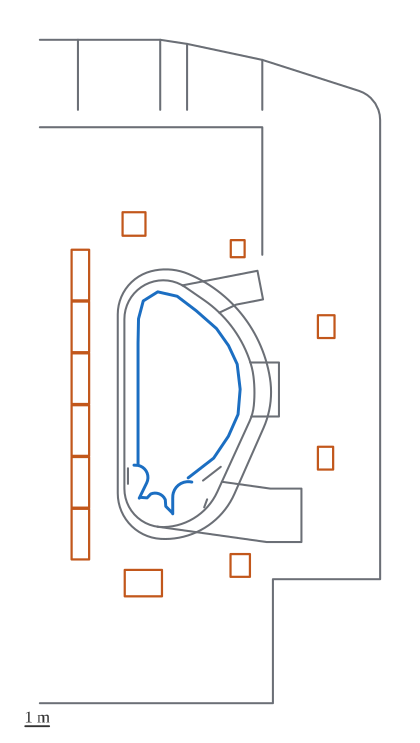

CFETR


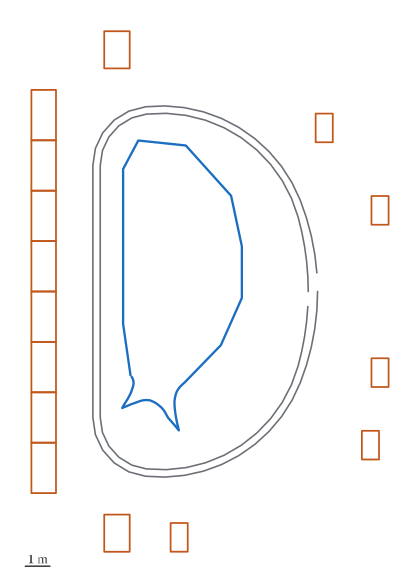

BEST


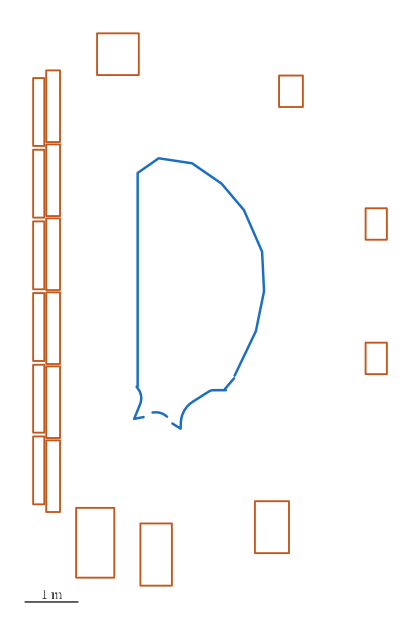

In [7]:
from IPython.display import SVG, display
for ident in ("iter", "cfetr", "best"):
    print(ident.upper())
    display(SVG(filename=str(FIGDIR / f"{ident}.svg")))

## 四 · 这一册证明了什么，没证明什么

**证明了**：六台机器的结构数据都能经 `fy` 写成 IMAS 数据入口、都能读回来，而且
**几何过一遍数据入口逐点不变**（上表「过一遍入口」一列）。

**没证明**：

* 入口里的数**全**对——那是 `test_device_export_integrity.py` 逐值核对的事，
  这一册只画几何；
* 这几份装置描述本身对——它们来自各自的公开来源（`fylite:source` 逐条记着），
  本仓校核的是**转换**，不是上游的数；
* 画不出来的部分不存在——`magnetics` 在这几台上多半是空的（源文档里就没有），
  图上因此没有诊断点。**留白就是留白**，不补一条像样的曲线。